In [ ]:
import json
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def resolve_dataset_path() -> Path:
    candidate_paths = [Path.cwd() / 'dataset', Path.cwd().parent / 'dataset']
    for candidate in candidate_paths:
        if candidate.exists():9  
            return candidate
    raise FileNotFoundError('Could not find the dataset folder. Place it at dataset/ or ../dataset/')

dataset_path = resolve_dataset_path()
project_root = dataset_path.parent
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)
test_images_dir = project_root / 'test_images'
test_images_dir.mkdir(exist_ok=True)
model_path = models_dir / 'plant_disease_transfer_learning.keras'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_FROZEN = 10
EPOCHS_FINE_TUNE = 5

print('Dataset path:', dataset_path)
print('Model path:', model_path)

TensorFlow version: 2.16.1
Dataset path: d:\downloads\dnn_Assign II\dataset
Model path: d:\downloads\dnn_Assign II\models\plant_disease_transfer_learning.keras


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.7, 1.3),
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    str(dataset_path),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    str(dataset_path),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print('Number of classes:', num_classes)
print('Class names:')
for class_name in class_names:
    print('-', class_name)

Found 33021 images belonging to 1 classes.
Found 8255 images belonging to 1 classes.
Number of classes: 1
Class names:
- PlantVillage


In [3]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

history_frozen = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks
)

Epoch 1/10


d:\ML_study\envs\study\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
d:\ML_study\envs\study\lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 554s 530ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 608s 589ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 498s 483ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 480s 466ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 481s 466ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 2.0000e-04
Epoch 6/10
1032/1

In [5]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetuned = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=callbacks
)

Epoch 1/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 546s 525ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 517s 501ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 487s 472ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 4/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 743s 720ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 2.0000e-06
Epoch 5/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 497s 481ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 2.0000

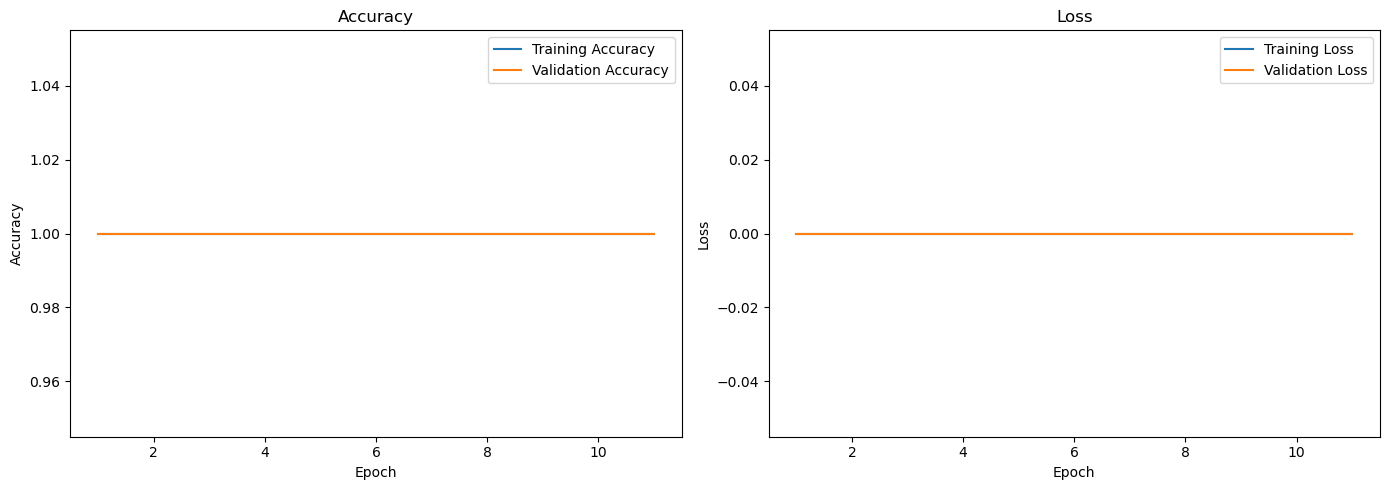

In [6]:
def merge_histories(*histories):
    merged = {}
    for history in histories:
        if history is None:
            continue
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

def plot_training_history(history_dict):
    epochs_range = range(1, len(history_dict['loss']) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history_dict['accuracy'], label='Training Accuracy')
    plt.plot(epochs_range, history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history_dict['loss'], label='Training Loss')
    plt.plot(epochs_range, history_dict['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

combined_history = merge_histories(history_frozen, history_finetuned)
plot_training_history(combined_history)

d:\ML_study\envs\study\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


258/258 ━━━━━━━━━━━━━━━━━━━━ 67s 258ms/step
              precision    recall  f1-score   support

PlantVillage       1.00      1.00      1.00      8255

    accuracy                           1.00      8255
   macro avg       1.00      1.00      1.00      8255
weighted avg       1.00      1.00      1.00      8255



d:\ML_study\envs\study\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


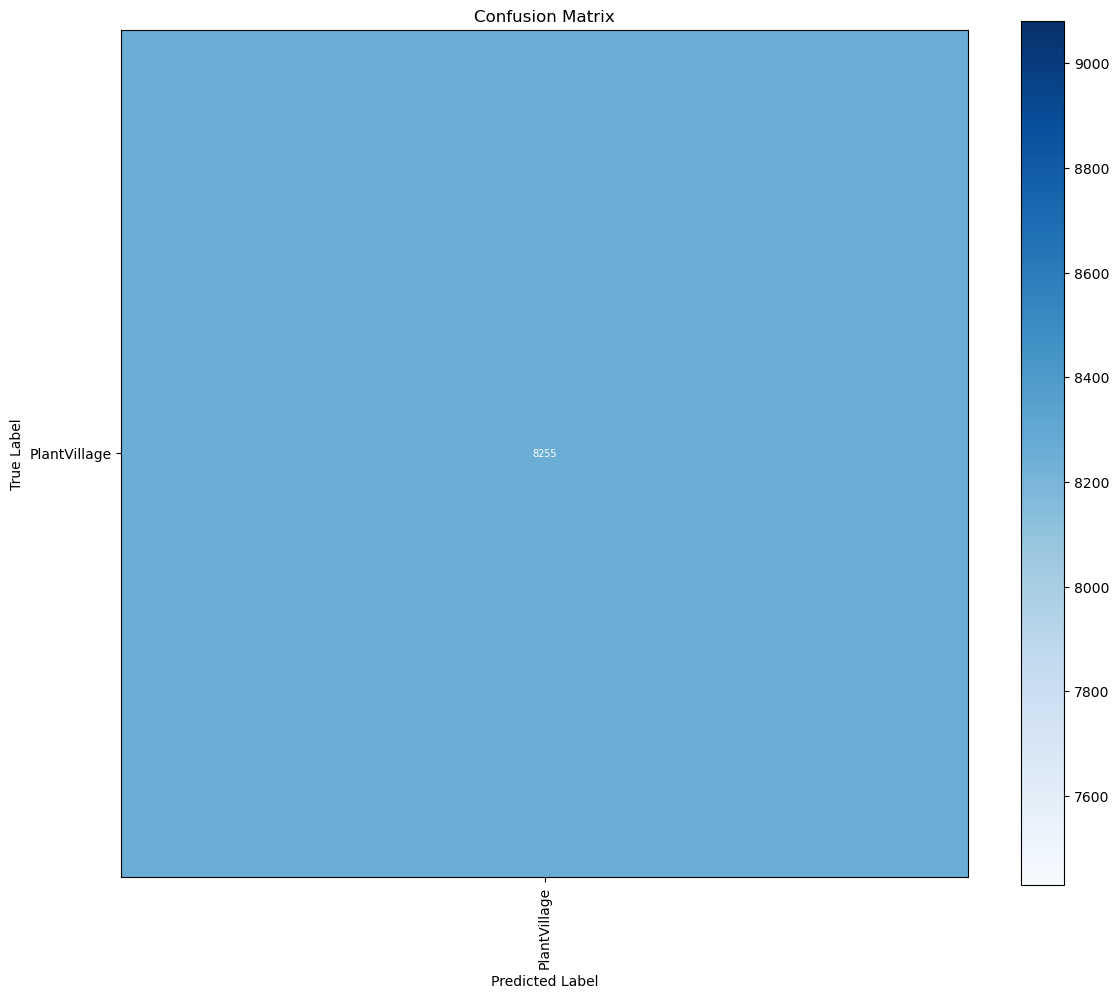

In [7]:
val_generator.reset()
validation_predictions = model.predict(val_generator, verbose=1)
y_pred = np.argmax(validation_predictions, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)

threshold = cm.max() / 2.0 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=7
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [8]:
def predict_single_image(image_path, model, class_names, img_size=IMG_SIZE):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'Could not read image: {image_path}')

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(image_rgb, img_size)
    normalized = resized.astype('float32') / 255.0
    batch = np.expand_dims(normalized, axis=0)

    probabilities = model.predict(batch, verbose=0)[0]
    class_index = int(np.argmax(probabilities))
    predicted_label = class_names[class_index]
    confidence = float(probabilities[class_index])

    return image_rgb, predicted_label, confidence, probabilities

sample_image_path = test_images_dir / 'sample_leaf.jpg'

if sample_image_path.exists():
    image_rgb, predicted_label, confidence, probabilities = predict_single_image(sample_image_path, model, class_names)
    plt.figure(figsize=(6, 6))
    plt.imshow(image_rgb)
    plt.title(f'Prediction: {predicted_label} ({confidence:.2%})')
    plt.axis('off')
    plt.show()
    print('Predicted label:', predicted_label)
    print('Confidence score:', round(confidence, 4))
else:
    print(f'Add a test image at: {sample_image_path}')

Add a test image at: d:\downloads\dnn_Assign II\test_images\sample_leaf.jpg


In [9]:
model.save(model_path)
print('Model saved to:', model_path)

reloaded_model = tf.keras.models.load_model(model_path)
print('Reloaded model type:', type(reloaded_model))

Model saved to: d:\downloads\dnn_Assign II\models\plant_disease_transfer_learning.keras
Reloaded model type: <class 'keras.src.models.functional.Functional'>
